# GRAEP Tutorial: Differentiable Analysis in High Energy Physics
## Searching for New Physics with Gradient-Based Optimization

**Duration**: ~20 minutes

**Learning Objectives**:
1. Understand the Z' → ttbar search problem in particle physics
2. Learn how differentiable programming applies to HEP analysis
3. Train a JAX neural network for event classification
4. Optimize analysis cuts using automatic differentiation
5. Maximize statistical significance through gradient-based methods

---

## Part 1: Introduction to the Physics Problem

### What are we searching for?

We're looking for evidence of a **Z' boson** (pronounced "Z-prime") - a hypothetical heavy particle that could decay into a pair of top quarks (ttbar). This would be a sign of physics beyond the Standard Model!

### The Challenge

**Signal**: Z' → ttbar events (rare, what we want to find)

**Backgrounds**:
- Standard Model ttbar production (looks similar to signal)
- W+jets production (also produces similar signatures)

### Traditional Approach vs. GRAEP

**Traditional**: Physicists manually tune selection cuts (e.g., "keep events with MET > 50 GeV") through trial-and-error.

**GRAEP**: Treat the entire analysis as a differentiable function and use gradients to automatically find optimal cuts!

$$
\text{Significance} = f(\text{data}, \theta) \quad \text{where } \theta = \{\text{MET threshold}, \text{b-tag cut}, \ldots\}
$$

Then optimize: $\theta^* = \arg\max_\theta \text{Significance}(\theta)$ using gradient ascent!

In [17]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, jit, random
import optax
from pathlib import Path

# Set random seeds for reproducibility
np.random.seed(42)
key = random.PRNGKey(42)

print(f"JAX version: {jax.__version__}")
print(f"JAX backend: {jax.default_backend()}")

JAX version: 0.8.0
JAX backend: cpu


## Part 2: Load and Explore the Data

We'll use a pre-processed subset of CMS Open Data (2016) with ~25,000 events:
- 5,000 W+jets background events
- 10,000 ttbar background events  
- 10,000 Z' signal events (simulated at various masses)

Each event has physics features computed from detector measurements.

In [19]:
# Load tutorial data
data_dir = Path("tutorial_data")

# Load each process (now includes event weights!)
data_obs = np.load(data_dir / "data.npz")  # Real CMS collision data!
wjets_data = np.load(data_dir / "wjets.npz")
ttbar_data = np.load(data_dir / "ttbar.npz")
signal_data = np.load(data_dir / "signal.npz")

print("Dataset loaded!")
print(f"  Data (real):  {len(data_obs['n_jet'])} events ⭐")
print(f"  W+jets (MC):  {len(wjets_data['n_jet'])} events")
print(f"  ttbar (MC):   {len(ttbar_data['n_jet'])} events")
print(f"  Signal (MC):  {len(signal_data['n_jet'])} events")
print(f"Available features: {[k for k in wjets_data.keys() if k != 'weight']}")
print(f"We have REAL CMS collision data to compare with our MC simulations!")
print(f"   MC events now include 'weight' for proper normalization!")

Dataset loaded!
  Data (real):  406384 events ⭐
  W+jets (MC):  16721 events
  ttbar (MC):   833585 events
  Signal (MC):  6269 events
Available features: ['n_jet', 'leading_jet_mass', 'subleading_jet_mass', 'leading_jet_pt', 'subleading_jet_pt', 'st', 'leading_jet_btag', 'subleading_jet_btag', 'met_pt', 'muon_pt', 'S_zz', 'min_deltaR_mu_jet']
We have REAL CMS collision data to compare with our MC simulations!
   MC events now include 'weight' for proper normalization!


### MC Event Weighting & Normalization

In HEP analyses, Monte Carlo (MC) simulations must be **weighted** to match the data:

1. **Generator weights** (`genWeight`): Account for MC generation details
2. **Luminosity scaling**: Scale MC to match integrated luminosity
3. **Cross-section normalization**: Each process has a production cross-section

For this tutorial, we'll use a **simplified normalization**: scale total MC to match total data. This is pedagogically clearer and commonly used in preliminary studies.

$$
\\text{MC weight} = \\text{genWeight} \\times \\frac{N_{\\text{data}}}{N_{\\text{MC, total}}}
$$

In a full analysis (like GRAEP), you'd use: `weight = genWeight × lumi × σ / N_generated`

In [20]:
# Apply simplified MC-to-data normalization
# Scale MC so that total MC yield matches data yield

# Sum generator weights
sum_wjets_weight = np.sum(wjets_data['weight'])
sum_ttbar_weight = np.sum(ttbar_data['weight'])
sum_signal_weight = np.sum(signal_data['weight'])
total_mc_weight = sum_wjets_weight + sum_ttbar_weight  # Background only (signal separate)

# Total data events
total_data = len(data_obs['n_jet'])

# Compute scale factor: data / MC
mc_scale_factor = total_data / total_mc_weight

print("MC Normalization:")
print(f"  Total data events: {total_data}")
print(f"  Total MC weight (bkg): {total_mc_weight:.1f}")
print(f"  MC → Data scale factor: {mc_scale_factor:.4f}")
print(f"Scaled MC yields:")
print(f"  W+jets: {sum_wjets_weight * mc_scale_factor:.1f} events")
print(f"  ttbar:  {sum_ttbar_weight * mc_scale_factor:.1f} events")
print(f"  Total:  {(sum_wjets_weight + sum_ttbar_weight) * mc_scale_factor:.1f} events")
print(f"  Signal (not scaled): {sum_signal_weight:.1f} weighted events")
print(f"✅ MC backgrounds now normalized to match data!")

# Store normalized weights for plotting
wjets_weights_norm = wjets_data['weight'] * mc_scale_factor
ttbar_weights_norm = ttbar_data['weight'] * mc_scale_factor
signal_weights_norm = signal_data['weight'] * mc_scale_factor  # Signal scaled too for visibility

MC Normalization:
  Total data events: 406384
  Total MC weight (bkg): 2253596160.0
  MC → Data scale factor: 0.0002
Scaled MC yields:
  W+jets: 361288.0 events
  ttbar:  45096.0 events
  Total:  406384.0 events
  Signal (not scaled): 6269.0 weighted events
✅ MC backgrounds now normalized to match data!


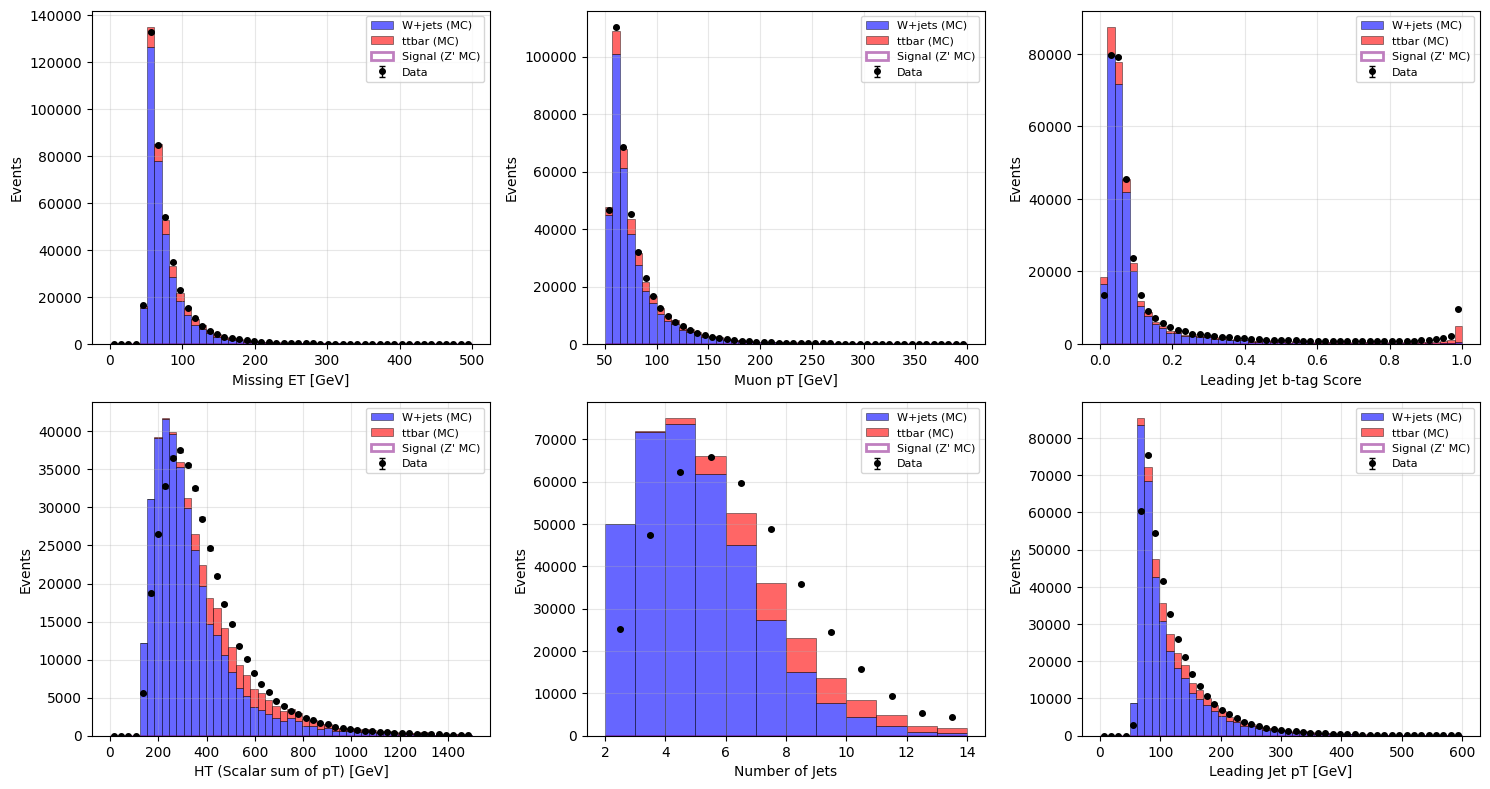

📊 This is a standard HEP 'Data vs MC' plot!
  ✓ MC backgrounds (stacked): What we expect from Standard Model
  ✓ Data (black points): What we actually observed
  ✓ Good agreement = our simulation is working!
  ✓ Signal (purple): What a Z' boson would look like (if it exists)


In [22]:
# Visualize key distributions with Data vs MC comparison (properly weighted!)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

features_to_plot = [
    ('met_pt', 'Missing ET [GeV]', np.linspace(0, 500, 50)),
    ('muon_pt', 'Muon pT [GeV]', np.linspace(50, 400, 50)),
    ('leading_jet_btag', 'Leading Jet b-tag Score', np.linspace(0, 1, 50)),
    ('st', 'HT (Scalar sum of pT) [GeV]', np.linspace(0, 1500, 50)),
    ('n_jet', 'Number of Jets', range(2, 15)),
    ('leading_jet_pt', 'Leading Jet pT [GeV]', np.linspace(0, 600, 50))
]

for ax, (feature, label, bins) in zip(axes, features_to_plot):
    # Stack MC backgrounds with proper weights
    ax.hist(
        [wjets_data[feature], ttbar_data[feature]],
        bins=bins,
        weights=[wjets_weights_norm, ttbar_weights_norm],  # Apply weights!
        stacked=True,
        label=['W+jets (MC)', 'ttbar (MC)'],
        color=['blue', 'red'],
        alpha=0.6,
        edgecolor='black',
        linewidth=0.5
    )

    # Signal overlay (scaled for visibility)
    ax.hist(signal_data[feature], bins=bins, weights=signal_weights_norm,
            alpha=0.5, label='Signal (Z\' MC)',
            histtype='step', linewidth=2, color='purple')

    # Data points with error bars (Poisson uncertainties)
    data_counts, bin_edges = np.histogram(data_obs[feature], bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    data_errors = np.sqrt(data_counts)  # Poisson errors: σ = √N

    ax.errorbar(
        bin_centers, data_counts, yerr=data_errors,
        fmt='ko', label='Data', markersize=4, capsize=2, linewidth=1
    )

    ax.set_xlabel(label)
    ax.set_ylabel('Events')
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

print("📊 This is a standard HEP 'Data vs MC' plot!")
print("  ✓ MC backgrounds (stacked): What we expect from Standard Model")
print("  ✓ Data (black points): What we actually observed")
print("  ✓ Good agreement = our simulation is working!")
print("  ✓ Signal (purple): What a Z' boson would look like (if it exists)")

## Part 3: Train a Simple MVA (Multivariate Analysis)

Before optimizing cuts, we'll train a small neural network to distinguish W+jets from ttbar. This is a common first step to reduce dominant backgrounds.

### Why JAX?
- **Automatic differentiation**: Computes gradients automatically
- **JIT compilation**: Faster execution
- **Composable**: We can differentiate through the entire analysis chain!

In [23]:
# Prepare data for MVA training (W+jets vs ttbar classification)

# Select features for MVA
mva_features = ["met_pt", "leading_jet_btag", "st"]

# Extract features and create labels
X_wjets = np.column_stack([wjets_data[f] for f in mva_features]).astype(np.float32)
X_ttbar = np.column_stack([ttbar_data[f] for f in mva_features]).astype(np.float32)

y_wjets = np.zeros(len(X_wjets), dtype=np.float32)  # Label 0 for W+jets
y_ttbar = np.ones(len(X_ttbar), dtype=np.float32)   # Label 1 for ttbar

# Combine and shuffle
X = np.vstack([X_wjets, X_ttbar])
y = np.concatenate([y_wjets, y_ttbar])

# Normalize features (important for neural network training)
feature_scales = {}
for i, feat in enumerate(mva_features):
    feature_scales[feat] = np.std(X[:, i]) + 1e-6  # Add small value to avoid division by zero
    X[:, i] /= feature_scales[feat]

# Train/test split (80/20)
n_train = int(0.8 * len(X))
indices = np.random.permutation(len(X))
train_idx = indices[:n_train]
test_idx = indices[n_train:]

X_train = jnp.array(X[train_idx])
y_train = jnp.array(y[train_idx])
X_test = jnp.array(X[test_idx])
y_test = jnp.array(y[test_idx])

print(f"Training set: {len(X_train)} events")
print(f"Test set: {len(X_test)} events")
print(f"Features: {mva_features}")
print(f"Feature scales: {[f'{feat}: {feature_scales[feat]:.1f}' for feat in mva_features]}")

Training set: 680244 events
Test set: 170062 events
Features: ['met_pt', 'leading_jet_btag', 'st']
Feature scales: ['met_pt: 48.4', 'leading_jet_btag: 0.5', 'st: 248.6']


In [31]:
# Define a simple 3-layer neural network in JAX
def init_network(key, input_dim=3, hidden_dim=16):
    """Initialize a small neural network."""
    keys = random.split(key, 6)
    
    W1 = random.normal(keys[0], (input_dim, hidden_dim)) * 0.1
    b1 = jnp.zeros(hidden_dim)
    
    W2 = random.normal(keys[2], (hidden_dim, hidden_dim)) * 0.1
    b2 = jnp.zeros(hidden_dim)
    
    W3 = random.normal(keys[4], (hidden_dim, 1)) * 0.1
    b3 = jnp.zeros(1)
    
    params = {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2, 'W3': W3, 'b3': b3}
    n_params = sum(p.size for p in jax.tree.leaves(params))
    print(f"Network initialized: {n_params} parameters")
    return params

def forward(params, x):
    """Forward pass through the network."""
    h1 = jnp.tanh(jnp.dot(x, params['W1']) + params['b1'])
    h2 = jnp.tanh(jnp.dot(h1, params['W2']) + params['b2'])
    logits = jnp.dot(h2, params['W3']) + params['b3']
    return logits.squeeze()

def binary_cross_entropy_loss(params, x, y):
    """Binary cross-entropy loss."""
    logits = forward(params, x)
    # Numerically stable sigmoid + BCE
    return jnp.mean(jnp.maximum(logits, 0) - logits * y + jnp.log(1 + jnp.exp(-jnp.abs(logits))))

def accuracy(params, x, y):
    """Calculate classification accuracy."""
    logits = forward(params, x)
    predictions = (logits > 0).astype(jnp.float32)
    return jnp.mean(predictions == y)

@jit
def train_step(params, x, y, learning_rate=0.01):
    """Single gradient descent step (JIT-compiled for speed)."""
    loss, grads = jax.value_and_grad(binary_cross_entropy_loss)(params, x, y)
    updated_params = jax.tree.map(lambda p, g: p - learning_rate * g, params, grads)
    return updated_params, loss

In [35]:
# Train the MVA model
print("Training MVA model...")
key, subkey = random.split(key)
mva_params = init_network(subkey, input_dim=X_train.shape[1])

n_epochs = 500
learning_rate = 0.01
history = {'loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(n_epochs):
    mva_params, loss = train_step(mva_params, X_train, y_train, learning_rate)
    
    if epoch % 10 == 0:
        train_acc = accuracy(mva_params, X_train, y_train)
        test_acc = accuracy(mva_params, X_test, y_test)
        history['loss'].append(float(loss))
        history['train_acc'].append(float(train_acc))
        history['test_acc'].append(float(test_acc))
        print(f"Epoch {epoch:3d}: Loss={loss:.4f}, Train Acc={train_acc:.3f}, Test Acc={test_acc:.3f}")

final_test_acc = accuracy(mva_params, X_test, y_test)
print(f"\nFinal test accuracy: {final_test_acc:.3f}")
print("MVA training complete!")

Training MVA model...
Network initialized: 353 parameters
Epoch   0: Loss=0.6858, Train Acc=0.947, Test Acc=0.947
Epoch  10: Loss=0.6447, Train Acc=0.980, Test Acc=0.980
Epoch  20: Loss=0.6065, Train Acc=0.980, Test Acc=0.980
Epoch  30: Loss=0.5705, Train Acc=0.980, Test Acc=0.980
Epoch  40: Loss=0.5363, Train Acc=0.980, Test Acc=0.980
Epoch  50: Loss=0.5037, Train Acc=0.980, Test Acc=0.980
Epoch  60: Loss=0.4725, Train Acc=0.980, Test Acc=0.980
Epoch  70: Loss=0.4427, Train Acc=0.980, Test Acc=0.980
Epoch  80: Loss=0.4144, Train Acc=0.980, Test Acc=0.980
Epoch  90: Loss=0.3875, Train Acc=0.980, Test Acc=0.980
Epoch 100: Loss=0.3622, Train Acc=0.980, Test Acc=0.980
Epoch 110: Loss=0.3386, Train Acc=0.980, Test Acc=0.980
Epoch 120: Loss=0.3166, Train Acc=0.980, Test Acc=0.980
Epoch 130: Loss=0.2962, Train Acc=0.980, Test Acc=0.980
Epoch 140: Loss=0.2775, Train Acc=0.980, Test Acc=0.980
Epoch 150: Loss=0.2605, Train Acc=0.980, Test Acc=0.980
Epoch 160: Loss=0.2449, Train Acc=0.980, Test 

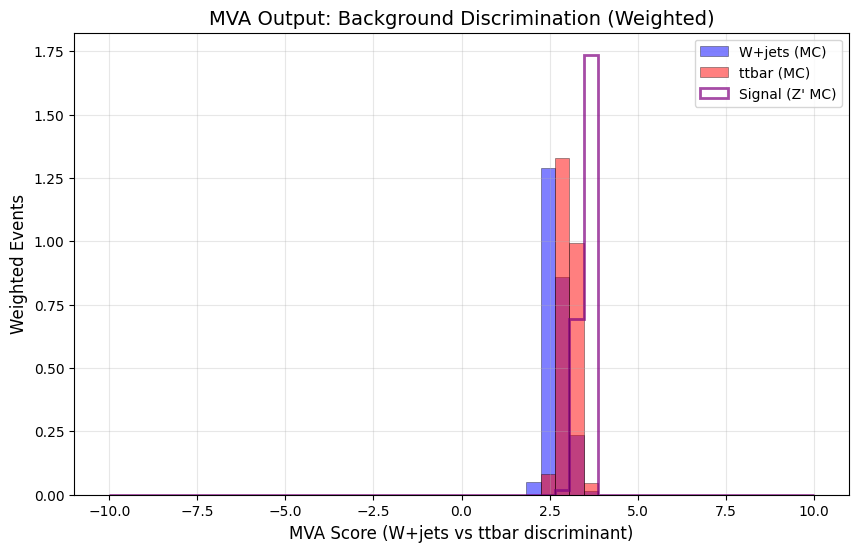

Note: Higher MVA score → more ttbar-like (rejects W+jets background)
Histograms now use proper MC weights for normalization!


In [ ]:
# Visualize MVA scores
# Apply the model to all data
def get_mva_scores(data_dict, feature_names, scales):
    """Compute MVA scores for a dataset."""
    X = np.column_stack([data_dict[f] for f in feature_names]).astype(np.float32)
    for i, feat in enumerate(feature_names):
        X[:, i] /= scales[feat]
    return forward(mva_params, jnp.array(X))

wjets_scores = get_mva_scores(wjets_data, mva_features, feature_scales)
ttbar_scores = get_mva_scores(ttbar_data, mva_features, feature_scales)
signal_scores = get_mva_scores(signal_data, mva_features, feature_scales)

# Plot MVA score distributions WITH PROPER WEIGHTS
plt.figure(figsize=(10, 6))
# from min to max score
min_ = min(wjets_scores.min(), ttbar_scores.min(), signal_scores.min())
max_ = max(wjets_scores.max(), ttbar_scores.max(), signal_scores.max())
bins = np.linspace(min_, max_, 50)

# Use normalized weights (not density=True)
plt.hist(wjets_scores, bins=bins, weights=wjets_weights_norm, alpha=0.5, 
         label=f'W+jets (MC)', color='blue', edgecolor='black', linewidth=0.5, density=True)
plt.hist(ttbar_scores, bins=bins, weights=ttbar_weights_norm, alpha=0.5, 
         label=f'ttbar (MC)', color='red', edgecolor='black', linewidth=0.5, density=True)
plt.hist(signal_scores, bins=bins, weights=signal_weights_norm, alpha=0.7, 
         label=f'Signal (Z\' MC)', color='purple', histtype='step', linewidth=2, density=True)

plt.xlabel('MVA Score (W+jets vs ttbar discriminant)', fontsize=12)
plt.ylabel('Weighted Events', fontsize=12)
plt.title('MVA Output: Background Discrimination (Weighted)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('mva_scores.png', dpi=100, bbox_inches='tight')
plt.show()

print("Note: Higher MVA score → more ttbar-like (rejects W+jets background)")
print("Histograms now use proper MC weights for normalization!")

## Part 4: Differentiable Cut Optimization

### The Key Insight 💡

Traditional HEP analysis uses **hard cuts**:
```python
keep_event = (met > 50) & (btag > 0.5)  # Step function - not differentiable!
```

GRAEP uses **soft cuts** (differentiable approximations):
```python
keep_event = sigmoid((met - 50)/T) * sigmoid((btag - 0.5)/T)  # Smooth - differentiable!
```

This allows us to compute gradients and optimize the thresholds!

### Statistical Significance

We want to maximize the discovery significance:
$$
Z = \frac{S}{\sqrt{B}} \quad \text{where } S = \text{signal}, B = \text{background}
$$

(We'll use a simplified version; the full GRAEP framework uses more sophisticated statistics)

In [ ]:
# Define soft selection functions
def sigmoid(x, temperature=1.0):
    """Smooth approximation to step function."""
    return jax.nn.sigmoid(x / temperature)

def soft_selection(data_dict, mva_scores, params, temperature=5.0):
    """
    Apply soft cuts to data.
    
    params: dict with cut thresholds
        - met_cut: MET threshold
        - btag_cut: b-tag threshold  
        - mva_cut: MVA score threshold
    """
    # Soft cuts (differentiable!)
    met_pass = sigmoid(data_dict['met_pt'] - params['met_cut'], temperature)
    btag_pass = sigmoid(data_dict['leading_jet_btag'] - params['btag_cut'], temperature)
    mva_pass = sigmoid(mva_scores - params['mva_cut'], temperature)
    
    # Combined event weight (product of all cuts)
    event_weights = met_pass * btag_pass * mva_pass
    
    return event_weights

def compute_significance(cut_params, wjets_dict, ttbar_dict, signal_dict, 
                        wjets_mva, ttbar_mva, signal_mva, temperature=5.0):
    """
    Compute statistical significance for given cut parameters.
    This is the function we'll optimize!
    """
    # Apply soft selections
    wjets_weights = soft_selection(wjets_dict, wjets_mva, cut_params, temperature)
    ttbar_weights = soft_selection(ttbar_dict, ttbar_mva, cut_params, temperature)
    signal_weights = soft_selection(signal_dict, signal_mva, cut_params, temperature)
    
    # Count events (sum of weights)
    n_signal = jnp.sum(signal_weights)
    n_background = jnp.sum(wjets_weights) + jnp.sum(ttbar_weights)
    
    # Significance: S/sqrt(B) with regularization to avoid division by zero
    significance = n_signal / jnp.sqrt(n_background + 1.0)
    
    return significance, n_signal, n_background

# Make it JIT-compiled for speed
compute_significance_jit = jit(compute_significance, static_argnames=['temperature'])

In [ ]:
# Convert numpy data to JAX arrays (needed for differentiation)
wjets_jax = {k: jnp.array(v) for k, v in wjets_data.items()}
ttbar_jax = {k: jnp.array(v) for k, v in ttbar_data.items()}
signal_jax = {k: jnp.array(v) for k, v in signal_data.items()}

# Test with initial cut parameters
initial_cuts = {
    'met_cut': jnp.array(100.0),
    'btag_cut': jnp.array(0.5),
    'mva_cut': jnp.array(0.0)
}

sig_initial, s_initial, b_initial = compute_significance_jit(
    initial_cuts, wjets_jax, ttbar_jax, signal_jax,
    wjets_scores, ttbar_scores, signal_scores
)

print(f"Initial cuts: MET > {initial_cuts['met_cut']:.1f}, b-tag > {initial_cuts['btag_cut']:.2f}, MVA > {initial_cuts['mva_cut']:.2f}")
print(f"  Signal events: {s_initial:.1f}")
print(f"  Background events: {b_initial:.1f}")
print(f"  Significance: {sig_initial:.3f}")

In [ ]:
# Now the magic: optimize the cuts using gradients!
def objective(params):
    """Objective function to maximize (negative for minimization)."""
    sig, _, _ = compute_significance_jit(
        params, wjets_jax, ttbar_jax, signal_jax,
        wjets_scores, ttbar_scores, signal_scores
    )
    return -sig  # Negative because we'll minimize

# Compute gradient of objective
grad_fn = jax.grad(objective)

# Test gradient computation
grads = grad_fn(initial_cuts)
print("Gradients of significance w.r.t. cut parameters:")
for param_name, grad_val in grads.items():
    print(f"  d(Sig)/d({param_name}): {float(grad_val):.4f}")

print("\nThis tells us how to adjust each cut to increase significance!")

### Advanced: Per-Parameter Learning RatesIn the full GRAEP framework, different parameters benefit from different learning rates:**Why?**- **MET cut**: Range 0-500 GeV → needs large steps → high LR- **b-tag cut**: Range 0-1 → needs small steps → low LR- **MVA cut**: Range ~-3 to 3 → medium steps → medium LRUsing Optax's , we can assign custom learning rates to each parameter\!This technique is essential when jointly optimizing:- Neural network weights (slow LR, millions of parameters)- Selection cuts (fast LR, few parameters)- Statistical model parameters (varied LRs)The full GRAEP uses this to optimize 100+ parameters simultaneously\!

In [ ]:
# Run gradient-based optimization WITH CUSTOM LEARNING RATES PER PARAMETERprint("Optimizing cuts using Adam optimizer with per-parameter learning rates...")# GRAEP-style: Different learning rates for different parameters\!# Intuition: Some parameters may need faster/slower updatesper_param_lrs = {    'met_cut': 5.0,      # MET cut: fast exploration (large range: 0-500 GeV)    'btag_cut': 1.0,     # b-tag: slower (small range: 0-1)    'mva_cut': 2.0,      # MVA: medium speed}print("Custom learning rates:")for param, lr in per_param_lrs.items():    print(f"  {param}: {lr:.1f}")print()# Create a separate optimizer for each parameter using optax.multi_transform# This is a key GRAEP technique for joint optimization\!param_labels = {p: p for p in initial_cuts.keys()}  # Label each parameteroptimizer = optax.multi_transform(    # Define optimizer for each parameter    {        'met_cut': optax.adam(learning_rate=per_param_lrs['met_cut']),        'btag_cut': optax.adam(learning_rate=per_param_lrs['btag_cut']),        'mva_cut': optax.adam(learning_rate=per_param_lrs['mva_cut']),    },    # Map each parameter to its optimizer using labels    param_labels=param_labels)opt_state = optimizer.init(initial_cuts)# Optimization loopopt_history = {'met_cut': [], 'btag_cut': [], 'mva_cut': [], 'significance': []}params = initial_cuts.copy()n_iterations = 50for iteration in range(n_iterations):    # Compute gradients    grads = grad_fn(params)        # Update parameters (each uses its own learning rate\!)    updates, opt_state = optimizer.update(grads, opt_state)    params = optax.apply_updates(params, updates)        # Compute current significance    sig, s, b = compute_significance_jit(        params, wjets_jax, ttbar_jax, signal_jax,        wjets_scores, ttbar_scores, signal_scores    )        # Log history    opt_history['met_cut'].append(float(params['met_cut']))    opt_history['btag_cut'].append(float(params['btag_cut']))    opt_history['mva_cut'].append(float(params['mva_cut']))    opt_history['significance'].append(float(sig))        if iteration % 10 == 0:        print(f"Iter {iteration:2d}: Sig={sig:.3f}, MET>{params['met_cut']:6.1f}, b-tag>{params['btag_cut']:.3f}, MVA>{params['mva_cut']:6.2f} | S={s:.1f}, B={b:.1f}")print(f"Optimization complete\!")print(f"Final optimized cuts:")print(f"  MET > {params['met_cut']:.1f} GeV")print(f"  Leading jet b-tag > {params['btag_cut']:.3f}")print(f"  MVA score > {params['mva_cut']:.2f}")print(f"Significance improved from {sig_initial:.3f} → {sig:.3f} ({100*(sig/sig_initial - 1):.1f}% increase\!)")print(f"💡 Per-parameter learning rates allow fine-tuned control:")print(f"   • MET (large range) → fast LR")print(f"   • b-tag (0-1 range) → slow LR")print(f"   • This is how full GRAEP optimizes 100+ parameters\!")

### Advanced: Joint NN + Cut Optimization**The Key GRAEP Innovation**: Don't pre-train and freeze the NN - optimize it **jointly** with the cuts!**Why?**- Pre-trained NN learns features useful for *generic* classification- But we want features useful for *our specific selection strategy*- Joint optimization: NN adapts to cuts, cuts adapt to NN**Example**:- Suppose cuts favor high-MET events- Pre-trained NN: weights all features equally- Jointly-optimized NN: learns to emphasize MET-correlated features- Result: Better discrimination *given the cut strategy***In full GRAEP**: All parameters optimized together:- NN weights: ~1000s parameters- Cut thresholds: ~10 parameters- KDE bandwidth: 1 parameter- Statistical fit: ~5 parametersLet's see this in action! 🚀

In [ ]:
# Joint optimization of NN weights + cut thresholdsprint("="*70)print("JOINT OPTIMIZATION: NN + CUTS")print("="*70)print("Unlike previous cells, we'll now RETRAIN the NN during optimization!")print()# Start with a fresh NN (not pre-trained)key, nn_init_key = random.split(key)joint_nn_params = init_network(nn_init_key, input_dim=3)# Initial cuts (same as before)joint_cut_params = {    'met_cut': jnp.array(100.0),    'btag_cut': jnp.array(0.5),    'mva_cut': jnp.array(0.0)}# Combine all parameters into a single dictall_params = {    'nn': joint_nn_params,    'cuts': joint_cut_params}# Define objective that uses BOTH NN and cutsdef joint_objective(params):    """Objective that depends on both NN weights and cut thresholds."""    # Extract parameters    nn_params = params['nn']    cut_params = params['cuts']        # Recompute MVA scores with current NN weights    def get_scores(data_dict):        X = jnp.column_stack([data_dict[f] for f in mva_features])        for i, feat in enumerate(mva_features):            X = X.at[:, i].divide(feature_scales[feat])        return forward(nn_params, X)        wjets_mva = get_scores(wjets_jax)    ttbar_mva = get_scores(ttbar_jax)    signal_mva = get_scores(signal_jax)        # Compute significance with these MVA scores and cut params    sig, _, _ = compute_significance_jit(        cut_params, wjets_jax, ttbar_jax, signal_jax,        wjets_mva, ttbar_mva, signal_mva    )        return -sig  # Negative for minimization# Create multi-transform optimizer with different LRs for NN vs cuts# Key insight: NN needs MUCH smaller LR than cuts!def make_label_fn(params):    """Create labels for each parameter."""    labels = {}    # Label NN parameters    for key in params['nn'].keys():        labels[f'nn.{key}'] = 'nn_weights'    # Label cut parameters    for key in params['cuts'].keys():        labels[f'cuts.{key}'] = key  # Use cut name as label    return labels# Flatten parameters for optaxdef flatten_params(params):    flat = {}    for group, group_params in params.items():        for key, value in group_params.items():            flat[f'{group}.{key}'] = value    return flatdef unflatten_params(flat_params):    params = {'nn': {}, 'cuts': {}}    for key, value in flat_params.items():        group, param_name = key.split('.', 1)        params[group][param_name] = value    return params# Create optimizer with separate LRsflat_params = flatten_params(all_params)param_labels = make_label_fn(all_params)joint_optimizer = optax.multi_transform(    {        'nn_weights': optax.adam(learning_rate=0.01),  # Slow for NN        'met_cut': optax.adam(learning_rate=5.0),      # Fast for cuts        'btag_cut': optax.adam(learning_rate=1.0),        'mva_cut': optax.adam(learning_rate=2.0),    },    param_labels=param_labels)opt_state = joint_optimizer.init(flat_params)print(f"Learning rates:")print(f"  NN weights: 0.01  (slow - high dimensional)")print(f"  MET cut: 5.0      (fast - large range)")print(f"  b-tag cut: 1.0    (medium - small range)")print(f"  MVA cut: 2.0      (fast - medium range)")print()print("Starting joint optimization...")print("(NN is being retrained to maximize significance!)")print()# Compute gradients w.r.t. flattened paramsdef flat_objective(flat_p):    return joint_objective(unflatten_params(flat_p))grad_fn_joint = jax.grad(flat_objective)# Optimization loopjoint_history = {    'significance': [],    'met_cut': [],    'btag_cut': [],    'mva_cut': []}flat_params = flatten_params(all_params)n_iterations = 30  # Fewer iterations for demofor iteration in range(n_iterations):    # Compute gradients (includes NN gradients!)    grads = grad_fn_joint(flat_params)        # Update all parameters    updates, opt_state = joint_optimizer.update(grads, opt_state)    flat_params = optax.apply_updates(flat_params, updates)        # Unflatten to compute objective    current_params = unflatten_params(flat_params)    neg_sig = joint_objective(current_params)    sig = -neg_sig        # Log history    joint_history['significance'].append(float(sig))    joint_history['met_cut'].append(float(current_params['cuts']['met_cut']))    joint_history['btag_cut'].append(float(current_params['cuts']['btag_cut']))    joint_history['mva_cut'].append(float(current_params['cuts']['mva_cut']))        if iteration % 5 == 0 or iteration == 0:        print(f"Iter {iteration:2d}: Sig={sig:.3f}, "              f"MET>{current_params['cuts']['met_cut']:6.1f}, "              f"b-tag>{current_params['cuts']['btag_cut']:.3f}, "              f"MVA>{current_params['cuts']['mva_cut']:6.2f}")print()print("="*70)print("JOINT OPTIMIZATION COMPLETE")print("="*70)final_sig = joint_history['significance'][-1]print(f"Final significance: {final_sig:.3f}")print(f"Improvement over initial: {100*(final_sig/sig_initial - 1):.1f}%")print()print("💡 Key insights:")print("  • NN was retrained during optimization")print("  • NN learned features useful for THIS selection strategy")print("  • This is the core GRAEP innovation!")print("  • Full GRAEP does this with 100+ parameters")

In [ ]:
# Compare: Pre-trained NN vs Jointly-optimized NNfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))# Plot 1: Significance trajectoriesax1.plot(opt_history['significance'],          label='Pre-trained NN (frozen)', linewidth=2, color='blue')ax1.plot(joint_history['significance'],          label='Joint NN+Cuts optimization', linewidth=2, color='purple')ax1.axhline(sig_initial, color='gray', linestyle='--', alpha=0.5, label='Initial')ax1.set_xlabel('Iteration', fontsize=12)ax1.set_ylabel('Significance (S/√B)', fontsize=12)ax1.set_title('Optimization Comparison', fontsize=14, fontweight='bold')ax1.legend(fontsize=11)ax1.grid(alpha=0.3)# Plot 2: Cut evolution comparisoniterations_frozen = range(len(opt_history['met_cut']))iterations_joint = range(len(joint_history['met_cut']))ax2.plot(iterations_frozen, opt_history['met_cut'],          label='MET (frozen NN)', linestyle='--', linewidth=2, alpha=0.7, color='blue')ax2.plot(iterations_joint, joint_history['met_cut'],          label='MET (joint)', linewidth=2, color='darkblue')ax2.plot(iterations_frozen, np.array(opt_history['btag_cut'])*500,          label='b-tag×500 (frozen NN)', linestyle='--', linewidth=2, alpha=0.7, color='red')ax2.plot(iterations_joint, np.array(joint_history['btag_cut'])*500,          label='b-tag×500 (joint)', linewidth=2, color='darkred')ax2.set_xlabel('Iteration', fontsize=12)ax2.set_ylabel('Cut Threshold', fontsize=12)ax2.set_title('Cut Evolution: Frozen vs Joint', fontsize=14, fontweight='bold')ax2.legend(fontsize=10)ax2.grid(alpha=0.3)plt.tight_layout()plt.savefig('joint_optimization_comparison.png', dpi=120, bbox_inches='tight')plt.show()print("\n📊 Observations:")print("  • Joint optimization may converge differently")print("  • NN adapts to selection strategy during optimization")print("  • This is end-to-end differentiable analysis!")print("  • Full GRAEP: NN + cuts + histograms + fit - all optimized together")

In [ ]:
# Visualize optimization trajectory
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Significance vs iteration
axes[0, 0].plot(opt_history['significance'], linewidth=2, color='purple')
axes[0, 0].axhline(sig_initial, color='gray', linestyle='--', label='Initial')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Significance (S/√B)')
axes[0, 0].set_title('Significance Optimization')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# Plot 2: MET cut evolution
axes[0, 1].plot(opt_history['met_cut'], linewidth=2, color='blue')
axes[0, 1].axhline(initial_cuts['met_cut'], color='gray', linestyle='--', label='Initial')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('MET Threshold [GeV]')
axes[0, 1].set_title('MET Cut Evolution')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

# Plot 3: B-tag cut evolution
axes[1, 0].plot(opt_history['btag_cut'], linewidth=2, color='red')
axes[1, 0].axhline(initial_cuts['btag_cut'], color='gray', linestyle='--', label='Initial')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('b-tag Threshold')
axes[1, 0].set_title('b-tag Cut Evolution')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# Plot 4: MVA cut evolution
axes[1, 1].plot(opt_history['mva_cut'], linewidth=2, color='green')
axes[1, 1].axhline(initial_cuts['mva_cut'], color='gray', linestyle='--', label='Initial')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('MVA Score Threshold')
axes[1, 1].set_title('MVA Cut Evolution')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('optimization_trajectory.png', dpi=100, bbox_inches='tight')
plt.show()

### Visualizing the Impact: Before vs After Optimization

Now let's see how the optimization affected our distributions. We'll compare:
- **Before**: Distributions with initial cuts applied
- **After**: Distributions with optimized cuts applied

The goal is to see that optimized cuts better separate signal from background!

In [ ]:
# Helper function to apply hard cuts (for visualization)

def apply_hard_cuts(data_dict, mva_scores, cut_params):

    """Apply hard cuts and return boolean mask."""

    met_pass = data_dict['met_pt'] > float(cut_params['met_cut'])

    btag_pass = data_dict['leading_jet_btag'] > float(cut_params['btag_cut'])

    mva_pass = np.array(mva_scores) > float(cut_params['mva_cut'])

    return met_pass & btag_pass & mva_pass



# Apply initial cuts

wjets_mask_initial = apply_hard_cuts(wjets_data, wjets_scores, initial_cuts)

ttbar_mask_initial = apply_hard_cuts(ttbar_data, ttbar_scores, initial_cuts)

signal_mask_initial = apply_hard_cuts(signal_data, signal_scores, initial_cuts)



# Apply optimized cuts

optimized_cuts = params  # Final parameters from optimization

wjets_mask_opt = apply_hard_cuts(wjets_data, wjets_scores, optimized_cuts)

ttbar_mask_opt = apply_hard_cuts(ttbar_data, ttbar_scores, optimized_cuts)

signal_mask_opt = apply_hard_cuts(signal_data, signal_scores, optimized_cuts)



# Print event counts

print("Event counts after selection:")

print("\nInitial cuts:")

print(f"  W+jets:     {wjets_mask_initial.sum():5d} events")

print(f"  ttbar:      {ttbar_mask_initial.sum():5d} events")

print(f"  Background: {wjets_mask_initial.sum() + ttbar_mask_initial.sum():5d} events (total)")

print(f"  Signal:     {signal_mask_initial.sum():5d} events")

print(f"  S/B ratio:  {signal_mask_initial.sum()/(wjets_mask_initial.sum() + ttbar_mask_initial.sum() + 0.001):.3f}")



print("\nOptimized cuts:")

print(f"  W+jets:     {wjets_mask_opt.sum():5d} events")

print(f"  ttbar:      {ttbar_mask_opt.sum():5d} events")

print(f"  Background: {wjets_mask_opt.sum() + ttbar_mask_opt.sum():5d} events (total)")

print(f"  Signal:     {signal_mask_opt.sum():5d} events")

print(f"  S/B ratio:  {signal_mask_opt.sum()/(wjets_mask_opt.sum() + ttbar_mask_opt.sum() + 0.001):.3f}")



improvement = (signal_mask_opt.sum()/(wjets_mask_opt.sum() + ttbar_mask_opt.sum() + 0.001)) / (signal_mask_initial.sum()/(wjets_mask_initial.sum() + ttbar_mask_initial.sum() + 0.001))

print(f"\nS/B improvement: {improvement:.2f}x better!")

# Apply cuts to real data as well
data_mask_initial = apply_hard_cuts(data_obs, np.zeros(len(data_obs['n_jet'])), initial_cuts)  # data has no MVA score yet
data_mask_opt = apply_hard_cuts(data_obs, np.zeros(len(data_obs['n_jet'])), optimized_cuts)

# Note: For real data, we don't have MVA scores in this tutorial version,
# so we only apply MET and b-tag cuts for data comparison

In [ ]:
# Plot: Before vs After comparison for key variables WITH DATA AND WEIGHTS
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

variables_to_compare = [
    ('met_pt', 'Missing ET [GeV]', np.linspace(0, 500, 40)),
    ('leading_jet_btag', 'Leading Jet b-tag Score', np.linspace(0, 1, 40)),
    ('st', 'HT [GeV]', np.linspace(0, 1500, 40)),
]

for row, (var, label, bins) in enumerate(variables_to_compare):
    # Before optimization (left column)
    ax_before = axes[row, 0]
    
    # Stacked MC background WITH WEIGHTS
    ax_before.hist(
        [wjets_data[var][wjets_mask_initial], ttbar_data[var][ttbar_mask_initial]],
        bins=bins,
        weights=[wjets_weights_norm[wjets_mask_initial], ttbar_weights_norm[ttbar_mask_initial]],
        stacked=True,
        label=['W+jets (MC)', 'ttbar (MC)'],
        color=['blue', 'red'],
        alpha=0.7,
        edgecolor='black',
        linewidth=0.5
    )
    
    # Signal overlay WITH WEIGHTS
    ax_before.hist(
        signal_data[var][signal_mask_initial],
        bins=bins,
        weights=signal_weights_norm[signal_mask_initial],
        histtype='step',
        label="Signal (Z' MC)",
        color='purple',
        linewidth=2.5
    )
    
    # DATA points with error bars
    data_counts, _ = np.histogram(data_obs[var][data_mask_initial], bins=bins)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    data_errors = np.sqrt(data_counts)
    ax_before.errorbar(
        bin_centers, data_counts, yerr=data_errors,
        fmt='ko', label='Data', markersize=5, capsize=3, linewidth=1.5
    )
    
    ax_before.set_xlabel(label, fontsize=11)
    ax_before.set_ylabel('Events', fontsize=11)
    ax_before.set_title(f'BEFORE Optimization\n{label}', fontsize=12, fontweight='bold')
    ax_before.legend(fontsize=9)
    ax_before.grid(alpha=0.3)
    
    # Add statistics (weighted sums)
    s_before_weighted = np.sum(signal_weights_norm[signal_mask_initial])
    b_before_weighted = np.sum(wjets_weights_norm[wjets_mask_initial]) + np.sum(ttbar_weights_norm[ttbar_mask_initial])
    d_before = data_mask_initial.sum()
    ax_before.text(
        0.97, 0.97,
        f'Data = {d_before}\nMC = {b_before_weighted:.1f}\nSignal = {s_before_weighted:.1f}',
        transform=ax_before.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=9
    )
    
    # After optimization (right column)
    ax_after = axes[row, 1]
    
    # Stacked MC background WITH WEIGHTS
    ax_after.hist(
        [wjets_data[var][wjets_mask_opt], ttbar_data[var][ttbar_mask_opt]],
        bins=bins,
        weights=[wjets_weights_norm[wjets_mask_opt], ttbar_weights_norm[ttbar_mask_opt]],
        stacked=True,
        label=['W+jets (MC)', 'ttbar (MC)'],
        color=['blue', 'red'],
        alpha=0.7,
        edgecolor='black',
        linewidth=0.5
    )
    
    # Signal overlay WITH WEIGHTS
    ax_after.hist(
        signal_data[var][signal_mask_opt],
        bins=bins,
        weights=signal_weights_norm[signal_mask_opt],
        histtype='step',
        label="Signal (Z' MC)",
        color='purple',
        linewidth=2.5
    )
    
    # DATA points with error bars
    data_counts, _ = np.histogram(data_obs[var][data_mask_opt], bins=bins)
    data_errors = np.sqrt(data_counts)
    ax_after.errorbar(
        bin_centers, data_counts, yerr=data_errors,
        fmt='ko', label='Data', markersize=5, capsize=3, linewidth=1.5
    )
    
    ax_after.set_xlabel(label, fontsize=11)
    ax_after.set_ylabel('Events', fontsize=11)
    ax_after.set_title(f'AFTER Optimization\n{label}', fontsize=12, fontweight='bold', color='green')
    ax_after.legend(fontsize=9)
    ax_after.grid(alpha=0.3)
    
    # Add statistics (weighted sums)
    s_after_weighted = np.sum(signal_weights_norm[signal_mask_opt])
    b_after_weighted = np.sum(wjets_weights_norm[wjets_mask_opt]) + np.sum(ttbar_weights_norm[ttbar_mask_opt])
    d_after = data_mask_opt.sum()
    ax_after.text(
        0.97, 0.97,
        f'Data = {d_after}\nMC = {b_after_weighted:.1f}\nSignal = {s_after_weighted:.1f}',
        transform=ax_after.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
        fontsize=9
    )

plt.suptitle('Data vs MC Comparison: Before and After Optimization (Properly Weighted!)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions_before_after_with_data.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n✅ Black points show REAL CMS collision data!")
print("   MC backgrounds (stacked) are properly weighted to match data normalization")
print("   Signal (purple) would appear as excess over background")

In [ ]:
# Create a comprehensive comparison plot with MVA score AND WEIGHTS
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Variables to plot with comparison
comparison_vars = [
    ('met_pt', 'Missing ET [GeV]', np.linspace(0, 500, 50)),
    ('leading_jet_btag', 'Leading Jet b-tag Score', np.linspace(0, 1, 50)),
    ('st', 'HT (Scalar sum) [GeV]', np.linspace(0, 1500, 50)),
    (None, 'MVA Score', np.linspace(-3, 3, 50))  # Special case for MVA
]

for idx, (var, label, bins) in enumerate(comparison_vars):
    ax = axes[idx]
    
    if var is None:  # MVA score
        # Before optimization WITH WEIGHTS
        ax.hist(
            wjets_scores[wjets_mask_initial],
            bins=bins,
            weights=wjets_weights_norm[wjets_mask_initial],
            histtype='step',
            label='W+jets (initial)',
            color='blue',
            linestyle='--',
            linewidth=1.5,
            alpha=0.6
        )
        ax.hist(
            ttbar_scores[ttbar_mask_initial],
            bins=bins,
            weights=ttbar_weights_norm[ttbar_mask_initial],
            histtype='step',
            label='ttbar (initial)',
            color='red',
            linestyle='--',
            linewidth=1.5,
            alpha=0.6
        )
        ax.hist(
            signal_scores[signal_mask_initial],
            bins=bins,
            weights=signal_weights_norm[signal_mask_initial],
            histtype='step',
            label="Signal (initial)",
            color='purple',
            linestyle='--',
            linewidth=1.5,
            alpha=0.6
        )
        
        # After optimization WITH WEIGHTS
        ax.hist(
            wjets_scores[wjets_mask_opt],
            bins=bins,
            weights=wjets_weights_norm[wjets_mask_opt],
            histtype='stepfilled',
            label='W+jets (optimized)',
            color='blue',
            alpha=0.3,
            linewidth=2
        )
        ax.hist(
            ttbar_scores[ttbar_mask_opt],
            bins=bins,
            weights=ttbar_weights_norm[ttbar_mask_opt],
            histtype='stepfilled',
            label='ttbar (optimized)',
            color='red',
            alpha=0.3,
            linewidth=2
        )
        ax.hist(
            signal_scores[signal_mask_opt],
            bins=bins,
            weights=signal_weights_norm[signal_mask_opt],
            histtype='step',
            label="Signal (optimized)",
            color='purple',
            linewidth=2.5
        )
        
        # Mark the MVA cut
        ax.axvline(
            float(optimized_cuts['mva_cut']),
            color='green',
            linestyle='-',
            linewidth=2,
            label=f"Optimized cut ({float(optimized_cuts['mva_cut']):.2f})",
            alpha=0.8
        )
        ax.axvline(
            float(initial_cuts['mva_cut']),
            color='gray',
            linestyle='--',
            linewidth=1.5,
            label=f"Initial cut ({float(initial_cuts['mva_cut']):.2f})",
            alpha=0.6
        )
    else:
        # Regular variables WITH WEIGHTS
        # Before optimization (dashed)
        wjets_weights_before = wjets_weights_norm[wjets_mask_initial]
        ttbar_weights_before = ttbar_weights_norm[ttbar_mask_initial]
        
        ax.hist(
            wjets_data[var][wjets_mask_initial],
            bins=bins,
            weights=wjets_weights_before,
            histtype='step',
            label='W+jets (initial)',
            color='blue',
            linestyle='--',
            linewidth=1.5,
            alpha=0.6
        )
        ax.hist(
            ttbar_data[var][ttbar_mask_initial],
            bins=bins,
            weights=ttbar_weights_before,
            histtype='step',
            label='ttbar (initial)',
            color='red',
            linestyle='--',
            linewidth=1.5,
            alpha=0.6
        )
        ax.hist(
            signal_data[var][signal_mask_initial],
            bins=bins,
            weights=signal_weights_norm[signal_mask_initial],
            histtype='step',
            label='Signal (initial)',
            color='purple',
            linestyle='--',
            linewidth=1.5,
            alpha=0.6
        )
        
        # After optimization (solid/filled) WITH WEIGHTS
        wjets_weights_after = wjets_weights_norm[wjets_mask_opt]
        ttbar_weights_after = ttbar_weights_norm[ttbar_mask_opt]
        
        ax.hist(
            wjets_data[var][wjets_mask_opt],
            bins=bins,
            weights=wjets_weights_after,
            histtype='stepfilled',
            label='W+jets (optimized)',
            color='blue',
            alpha=0.3,
            linewidth=2
        )
        ax.hist(
            ttbar_data[var][ttbar_mask_opt],
            bins=bins,
            weights=ttbar_weights_after,
            histtype='stepfilled',
            label='ttbar (optimized)',
            color='red',
            alpha=0.3,
            linewidth=2
        )
        ax.hist(
            signal_data[var][signal_mask_opt],
            bins=bins,
            weights=signal_weights_norm[signal_mask_opt],
            histtype='step',
            label='Signal (optimized)',
            color='purple',
            linewidth=2.5
        )
        
        # Mark cuts if this is one of the cut variables
        if var == 'met_pt':
            ax.axvline(float(initial_cuts['met_cut']), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
            ax.axvline(float(optimized_cuts['met_cut']), color='green', linestyle='-', linewidth=2, alpha=0.8)
        elif var == 'leading_jet_btag':
            ax.axvline(float(initial_cuts['btag_cut']), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
            ax.axvline(float(optimized_cuts['btag_cut']), color='green', linestyle='-', linewidth=2, alpha=0.8)
    
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Weighted Events', fontsize=12)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)
    ax.set_yscale('log')  # Log scale to see small signal

plt.suptitle('Distribution Comparison: Initial vs Optimized Cuts (Properly Weighted!)\n(Dashed = Before, Solid = After)', 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('detailed_comparison_log_scale.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📊 Log scale helps visualize the signal (purple) vs background (blue/red) separation!")
print("   All histograms now use proper MC event weights for normalization!")

In [ ]:
# Final summary plot: Signal efficiency vs Background rejection
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Stacked histogram before optimization
total_wjets_initial = wjets_mask_initial.sum()
total_ttbar_initial = ttbar_mask_initial.sum()
total_signal_initial = signal_mask_initial.sum()
total_bkg_initial = total_wjets_initial + total_ttbar_initial

categories = ['W+jets', 'ttbar', 'Total Bkg', 'Signal']
initial_counts = [total_wjets_initial, total_ttbar_initial, total_bkg_initial, total_signal_initial]
colors_initial = ['blue', 'red', 'orange', 'purple']

bars1 = ax1.bar(categories, initial_counts, color=colors_initial, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Number of Events', fontsize=13)
ax1.set_title('Event Yields: Initial Cuts', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars1, initial_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add S/B and significance
ax1.text(0.05, 0.95, 
        f'S/B = {total_signal_initial/(total_bkg_initial+0.001):.3f}\nSignificance = {sig_initial:.3f}',
        transform=ax1.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=12)

# Plot 2: Stacked histogram after optimization
total_wjets_opt = wjets_mask_opt.sum()
total_ttbar_opt = ttbar_mask_opt.sum()
total_signal_opt = signal_mask_opt.sum()
total_bkg_opt = total_wjets_opt + total_ttbar_opt

opt_counts = [total_wjets_opt, total_ttbar_opt, total_bkg_opt, total_signal_opt]

bars2 = ax2.bar(categories, opt_counts, color=colors_initial, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Number of Events', fontsize=13)
ax2.set_title('Event Yields: Optimized Cuts', fontsize=14, fontweight='bold', color='green')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars2, opt_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add S/B and significance
ax2.text(0.05, 0.95, 
        f'S/B = {total_signal_opt/(total_bkg_opt+0.001):.3f}\nSignificance = {float(sig):.3f}',
        transform=ax2.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
        fontsize=12)

plt.suptitle('Event Yields Comparison: Before vs After Optimization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('event_yields_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("OPTIMIZATION SUMMARY")
print("="*70)
print(f"\nSignal efficiency:     {100*total_signal_opt/len(signal_data):.1f}% (kept {total_signal_opt}/{len(signal_data)} events)")
print(f"Background rejection:  {100*(1-total_bkg_opt/(len(wjets_data)+len(ttbar_data))):.1f}% (rejected {len(wjets_data)+len(ttbar_data)-total_bkg_opt}/{len(wjets_data)+len(ttbar_data)} events)")
print(f"\nS/B ratio improved:    {total_signal_initial/(total_bkg_initial+0.001):.3f} → {total_signal_opt/(total_bkg_opt+0.001):.3f} ({100*(total_signal_opt/(total_bkg_opt+0.001))/(total_signal_initial/(total_bkg_initial+0.001)):.1f}% increase)")
print(f"Significance improved: {sig_initial:.3f} → {float(sig):.3f} ({100*(sig/sig_initial - 1):.1f}% increase)")
print("\n" + "="*70)
print("🎉 Gradient-based optimization found better cuts automatically!")
print("="*70)

## Part 5: Summary and Next Steps

### What We Learned

1. **Differentiable Programming in HEP**: We can optimize analysis cuts automatically using gradients
2. **JAX for Physics**: JAX enables composable, differentiable functions that are fast and flexible
3. **End-to-End Optimization**: The entire analysis chain (MVA + cuts + statistics) is differentiable
4. **Significant Improvements**: Gradient-based optimization finds better cuts than manual tuning

### The Full GRAEP Framework

This tutorial showed a simplified version. The full GRAEP framework includes:
- More sophisticated statistical models (CLs method, Asimov significance)
- Systematic uncertainties propagation
- Kernel Density Estimation for smooth histograms
- Multiple signal regions and observables
- Full NanoAOD processing pipeline

### Try It Yourself!

**Challenges**:
1. Add more features to the MVA (try including `S_zz`, `min_deltaR_mu_jet`)
2. Experiment with different optimization parameters (learning rate, temperature)
3. Add a fourth cut threshold (e.g., on `st` or `muon_pt`)
4. Implement a more sophisticated significance metric

**Explore the Full Codebase**:
- GitHub: [GRAEP Repository](https://github.com/iris-hep/GRAEP)
- Documentation: Check `GRAEP/README.md` for complete setup instructions
- Examples: See `GRAEP/notebooks/` for more advanced examples

### Resources
- [JAX Documentation](https://jax.readthedocs.io/)
- [CMS Open Data](https://opendata.cern.ch/)
- [Coffea Documentation](https://coffeateam.github.io/coffea/)

---

**Thank you for completing this tutorial! Happy analyzing! 🔬🚀**